In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# örnek 1 verisetini çekip inceleme yapıyoruz
b1 = pd.read_csv('sample/Banana D1.csv')

In [3]:
# verimiz 9 sensör ve 1 zaman parametresinden oluşmaktadır
b1.head(1)

,Ticks,MQ2,MQ3,MQ4,MQ5,MQ6,MQ7,MQ8,MQ9,MQ135
0,1648640854091,54,82,79,19,70,36,63,61,493


In [4]:
# 5 gün için veri setlerini birleştiriyoruz
# tahminimizi güne göre yapacağız. y = kaçıncı gün?

# teknik detaylar:
# 1. verisetlerini birleştirmeden önce kaçıncı gün olduklarını label ekledik
# 2. concat işlemi for içersinde tekrar tekrar yapmak çok yorucudur, onun yerine listede toplayıp 1 concat yaptık
# 3. concat içersine ilk olarak 'liste' parametresi ister.  daha sonrasında ise:
#    a. ignore_index : indeksleri sıfırlar
#    b. axis : 0 ise dikey olarak verileri ekler varsayılandır, 1 ise yatay olarak ekler
#    c. join : 'inner' sadece ortak olanları birleştirir. 'outer'(varsayılan) her şeyi birleştirir.
banana_df = pd.DataFrame()
temp_ls = []
for i in range(1, 6):
    yol = f'sample/Banana D{i}.csv'
    temp_df = pd.read_csv(yol)
    temp_df['gün'] = i
    temp_ls.append(temp_df) 
    
banana_df = pd.concat(temp_ls , ignore_index= True)

In [5]:
# 82k veri olduğu için, işlemi başarılı sayıyorum
banana_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82505 entries, 0 to 82504
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Ticks   82505 non-null  int64
 1   MQ2     82505 non-null  int64
 2   MQ3     82505 non-null  int64
 3   MQ4     82505 non-null  int64
 4   MQ5     82505 non-null  int64
 5   MQ6     82505 non-null  int64
 6   MQ7     82505 non-null  int64
 7   MQ8     82505 non-null  int64
 8   MQ9     82505 non-null  int64
 9   MQ135   82505 non-null  int64
 10  gün     82505 non-null  int64
dtypes: int64(11)
memory usage: 6.9 MB


In [6]:
# ticks: Unix zamanı, 1 Ocak 1970 saat 00:00:00'dan (UTC) bu yana geçen süreyi ifade eder. zaman damgasıdır. milisaniye.
# model eğitiminde okunabilirliği ve işlenimi kolaylaştırmak adına miladi takvim türüne çevirdik
# ticks sütununu attık çünkü gerek kalmadı
banana_df['date'] = pd.to_datetime(banana_df['Ticks'], unit='ms')
banana_df.drop(columns = ['Ticks'], inplace = True)

In [7]:
banana_df.head(1)

,MQ2,MQ3,MQ4,MQ5,MQ6,MQ7,MQ8,MQ9,MQ135,gün,date
0,54,82,79,19,70,36,63,61,493,1,2022-03-30 11:47:34.091


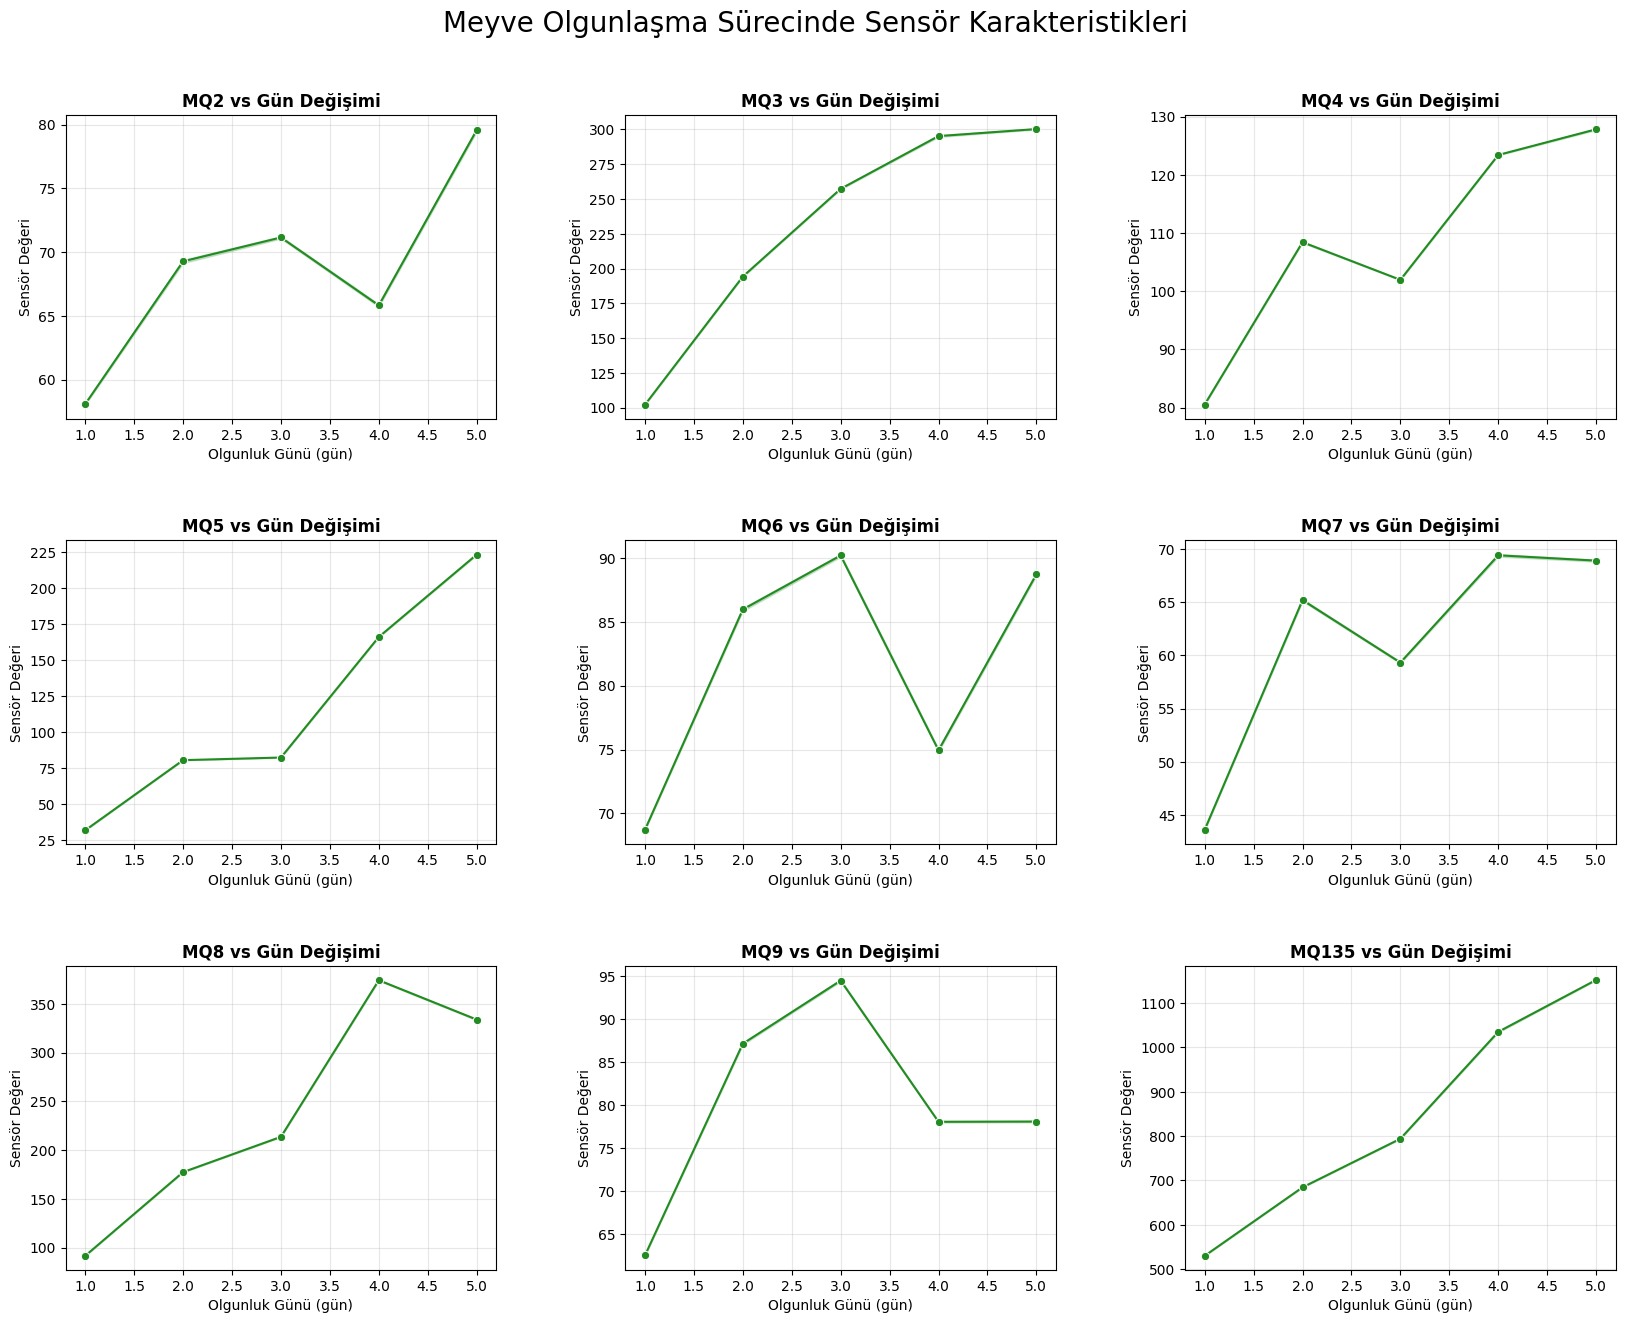

In [8]:
# plt ve sns çok bilmediğimden, gemini ile hangi sensörleri kullanmam gerektiğine karar vermek için lineplot yaptırttım
plt.figure(figsize=(20, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
sensors = ['MQ2', 'MQ3', 'MQ4', 'MQ5', 'MQ6', 'MQ7', 'MQ8', 'MQ9', 'MQ135']

for i, sensor in enumerate(sensors):
    plt.subplot(3, 3, i+1)
    
    # Gün bazında sensör ortalamalarını çiziyoruz
    sns.lineplot(data=banana_df, x='gün', y=sensor, marker='o', color='forestgreen')
    
    plt.title(f'{sensor} vs Gün Değişimi', fontsize=12, fontweight='bold')
    plt.xlabel('Olgunluk Günü (gün)')
    plt.ylabel('Sensör Değeri')
    plt.grid(True, alpha=0.3)

plt.suptitle('Meyve Olgunlaşma Sürecinde Sensör Karakteristikleri', fontsize=20, y=0.95)
plt.show()

# 🍌 Meyve Olgunluk Takibi: Sensör Analizi ve Teknik Altyapı

---

## 1. 🔬 MQ Serisi Sensörlerin Çalışma Mantığı (MOS Teknolojisi)
Seçtiğimiz tüm sensörler **Metal Oksit Yarı İletken (MOS)** tabanlıdır.

* **Donanım Yapısı:** İçlerinde minik bir ısıtıcı ve kalay dioksit ($SnO_2$) kaplı seramik bir yapı bulunur.
* **Çalışma Prensibi:** Isıtıcı katmanı yüksek sıcaklığa çıkarır. Temiz havada oksijen iyonları yüzeye yapışarak elektron akışını engeller (**yüksek direnç**).
* **Gaz Algılama:** Ortama hedef gaz girdiğinde yüzeydeki oksijenle tepkimeye girer, hapsolmuş elektronlar serbest kalır (**düşük direnç**).
* **Veri Çıkışı:** Gaz yoğunluğu arttıkça direnç düşer; biz bu değişimi **voltaj** olarak okuruz.

---

## 2. 🎯 Seçilen "Altın Üçlü" Sensörler
Analiz ettiğimiz **82,505 satırlık** veri setinde, 5 günlük süreçte en kararlı "imzayı" bırakan sensörlerimizi belirledik:

1. **MQ3 (Alkol & Etanol):** 🧪
   * **Neden?** Meyveler olgunlaştıkça şeker parçalanır ve etanol yayılır. Grafikteki en kusursuz ve doğrusal yükseliş bu sensöre aittir.
2. **MQ135 (Hava Kalitesi - $NH_3$, $CO_2$):** 🌬️
   * **Neden?** Kapalı alanlardaki toplam organik uçucu bileşik (TVOC) artışını takip eder. En geniş dinamik aralığa (500-1100+) sahip sensörümüzdür.
3. **MQ5 (Metan & LPG):** 🔥
   * **Neden?** Bozulma sürecinde salınan metan bazlı bileşikleri yakalayarak MQ3 ve MQ135'e "destekleyici" veri sağlar.

---

## 3. ⚠️ Gürültü Faktörleri & Sistemsel Gereksinimler
Veri biliminde bu sensörler "kör" kabul edilir; yani ortamdaki her değişikliği gaz zannedebilirler. Bu **Gürültüyü (Noise)** yönetmek için şunlara dikkat edilmelidir:

* **Sıcaklık ve Nem 🌡️:** En büyük hata kaynağıdır. Sensör direnci hava durumuna göre değişir. Çözüm olarak sisteme bir **DHT22** sensörü eklenip veri normalize edilmelidir.
* **Isınma Süresi (Preheating) ⏳:** Sensörlerin stabil sonuç vermesi için iç ısıtıcının belirli bir süre çalışması gerekir. Verideki ani zıplamalar bazen yetersiz ısınmadan kaynaklanır.
* **Çapraz Hassasiyet 🔀:** Örneğin MQ3 alkole hassastır ama yoğun dumanı da alkol olarak algılayabilir. Bu karmaşıklığı aşmak için çoklu sensör (**Sensor Fusion**) yapısı kullanıyoruz.

### 📊 Ölçeklendirme (Scaling) Yöntemlerinin Karşılaştırılması

| **Yöntem** | **Matematiksel Mantık** | **Avantajları** | **Dezavantajları** |
| :--- | :--- | :--- | :--- |
| **StandardScaler** | Ortalama ($\mu$) = 0, Standart Sapma ($\sigma$) = 1 yapar. | Çoğu ML algoritması için standarttır. | Veri normal dağılıma (Gaussian) yakın değilse performansı düşebilir. |
| **MinMaxScaler** | Veriyi 0-1 (veya -1 ile 1) arasına hapseder. | Görüntü işleme ve Derin Öğrenme modellerinde çok popülerdir. | Uç değerler (**outliers**) tüm veriyi küçücük bir aralığa sıkıştırabilir. |
| **RobustScaler** | Medyanı çıkarır, Çeyreklikler Açıklığına (IQR) böler. | **Uç değerlere (hatalı sensör okumaları vb.) karşı bağışıktır.** | Verinin istatistiksel dağılımını tam olarak yansıtmayabilir. |
| **Normalizer** | Her bir örneği (satırı) birim uzunluğa sahip olacak şekilde ölçekler. | Metin madenciliği gibi "yön" ve "oran" odaklı verilerde harikadır. | Sensör verileri gibi genelde sütun bazlı verilerde tercih edilmez. |

---

### 💡 Neden StandardScaler Seçtik?

1. **Sensör Farklılıkları:** `MQ135` değerleri 1100'lerde seyrederken `MQ3` değerleri 300'lerde kalmaktadır. Modelin "büyük olan daha önemlidir" hatasına düşmesini engellemek için bu verileri "standart sapma" bazında eşitledik.
2. **Algoritma Gereksinimi:** Birazdan kullanacağımız **k-NN** ve **SVM** modelleri, verilerin sıfır etrafında merkezlenmiş olmasından (Standardization) hoşlanır.
3. **Genelleme Yeteneği:** `MinMaxScaler` kullansaydık, ileride 1100 değerinden daha büyük bir koku seviyesi (örneğin 1500) gelirse ölçekleme sistemimiz bozulabilirdi. `StandardScaler` bu tip yeni verileri "ortalamadan şu kadar uzak" diye tanımlayabildiği için daha esnektir.

In [9]:
# verisetindeki bağımsız değişkenleri (x) ve bağımlı değişkenleri (y) belirledik
# 80-20 olarak böldük
# scale ettik, verilerin değerini eşitlemeye çalıştık

from sklearn.model_selection import train_test_split as ttt
from sklearn.preprocessing import StandardScaler

x = banana_df[['MQ3', 'MQ5', 'MQ135']] 
y = banana_df['gün']

x_train, x_test, y_train, y_test = ttt(x,y, test_size= 0.2, random_state=42)

scaler = StandardScaler()
# scaleri train ile fit ettik, sonra testi transform ettik
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

üstteki kod bloğunun notları:

* [[]] pandas dataframe döndürür(2D), bağımsız değişkenler 1 den çok olduğu için gereklidir
* [] sadece pandas series döndürücek(1D), bağımlı değişken için yeterlidir, çünkü 1 adet veri sütunu vardır


standardscaler:
* fit: train seti üzerinde ortalama($\mu$) ve standart sapma($\sigma$) değerlerini öğreniyoruz
* transform: tüm veri setini(train - test) öğrenilenlere göre aralığa indirgeniyor
* sonuç: ortalama = 0 , std sapma = 1
$$z = \frac{x - \mu}{\sigma}$$


### 📊 Model Başarı Metrikleri ve Denklemleri

| **Metrik** | **Denklem (Formula)** | **Tanım** | **Ne Zaman Kullanılır?** |
| :--- | :---: | :--- | :--- |
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | Toplam doğru tahmin oranıdır. | Sınıf dağılımı dengeliyse (D1-D5 satır sayıları yakınsa) tercih edilir. |
| **Precision** | $\frac{TP}{TP + FP}$ | Doğru pozitif tahminlerin, tüm pozitif tahminlere oranıdır. | Yanlış pozitif tahminin (Hatalı alarm) maliyeti yüksekse kritiktir. |
| **Recall** | $\frac{TP}{TP + FN}$ | Gerçek pozitiflerin ne kadarının yakalanabildiğinin oranıdır. | Gerçek bir durumu kaçırmanın (Örn: Bozulmayı tespit edememek) maliyeti yüksekse en önemli metriktir. |
| **F1-Score** | $2 \times \frac{Precision \times Recall}{Precision + Recall}$ | Precision ve Recall'un harmonik ortalamasıdır. | Sınıflar arasında dengesizlik olduğunda veya her iki metrik de önemli olduğunda kullanılır. |

---

#### **🔍 Denklem Terimleri Sözlüğü:**
* **TP (True Positive):** Modelin "Gün 5" dediği ve gerçekten "Gün 5" olanlar.
* **TN (True Negative):** Modelin "Gün 5 Değil" dediği ve gerçekten "Gün 5" olmayanlar.
* **FP (False Positive):** Modelin "Gün 5" dediği ama aslında "Gün 1" olanlar (Hatalı Alarm).
* **FN (False Negative):** Meyve aslında "Gün 5" ama modelin bunu "Gün 1" sanması (Tehlikeli Hata!).

---

### 💡 Proje Özelinde Kritik Analiz:
Hasat zamanı projemizde **Recall** değerinin özellikle **Gün 5** için yüksek olması istenir. Eğer model, etanol seviyesi artmış bir meyveyi (Gün 5) sağlıklı sanarsa (FN), bu durum depodaki diğer meyvelerin de hızla bozulmasına neden olabilir.

## 1. model: KNN
gelen koku verisinden kaçıncı gün olabileceğini, önceden kayıtlı k adet koku verilerine en yakın olan öklid mesafesine göre sınıflandırma tahmini gerçekleştirir.

parametreler:

* n_neighbors: komşu sayısı, küçük = overfitting büyük = underfitting
* weights: komşu oy gücü (uniform: eşit, distance: yakındaki daha etkili)
* metric: mesafe hesabı (euclidean: öklid, manhattan: dik açılı)
* algorithm: matematiksel yapıdır (anlamadım, anlatamam)

In [10]:
from sklearn.neighbors import KNeighborsClassifier as KNN

knn = KNN(n_neighbors = 5)
knn.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [11]:
y_pred_knn = knn.predict(x_test_scaled)

In [12]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred_knn)
acc

0.9987273498575844

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      5438
           2       1.00      0.99      1.00      2542
           3       0.99      1.00      1.00      2663
           4       1.00      1.00      1.00      2949
           5       1.00      1.00      1.00      2909

    accuracy                           1.00     16501
   macro avg       1.00      1.00      1.00     16501
weighted avg       1.00      1.00      1.00     16501



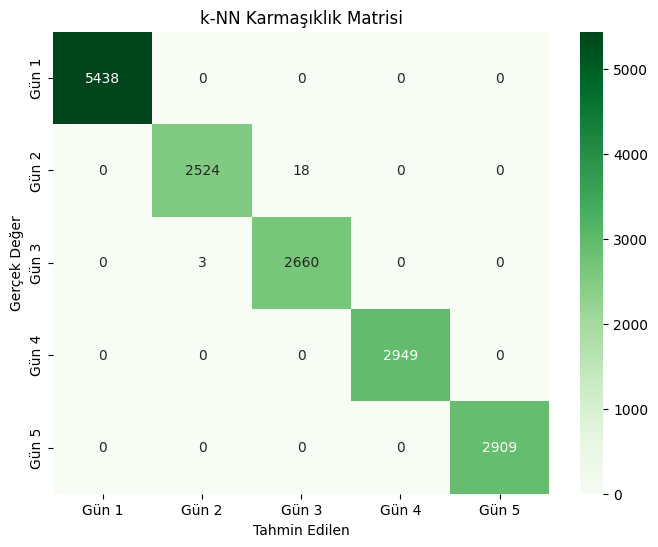

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=[f'Gün {i}' for i in range(1, 6)],
            yticklabels=[f'Gün {i}' for i in range(1, 6)])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('k-NN Karmaşıklık Matrisi')
plt.show()

# 2. model: Random Foreset
* ağaçlardaki oy çokluğuna bakar
* 1-2 sensörün ortalamasının düşük olması sonucu çok değiştirtmez
* gürültüye karşı dirençli olduğu için bu proje için iyi bir model olduğunu düşünüyorum

parametreler:

* n_estimators: ağaç sayısı
* max_depth: ağacın ne kadar derinleşebileceği(çok derin = overfitting, az derin = underfitting)
* min_samples_split: düğümü bölmek için gerekli min örnek sayısı
* random_state: kontrollü rastgelelik
* criterion: bölünme kalitesi ölçüm yöntemi


In [15]:
from sklearn.ensemble import RandomForestClassifier as RFC

rf = RFC(n_estimators = 100, random_state = 42)

In [16]:
rf.fit(x_train_scaled,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
y_pred_rf = rf.predict(x_test_scaled)

In [18]:
accuracy_score(y_test, y_pred_rf)

0.998424337918914

In [19]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      5438
           2       1.00      0.99      1.00      2542
           3       0.99      1.00      1.00      2663
           4       1.00      1.00      1.00      2949
           5       1.00      1.00      1.00      2909

    accuracy                           1.00     16501
   macro avg       1.00      1.00      1.00     16501
weighted avg       1.00      1.00      1.00     16501



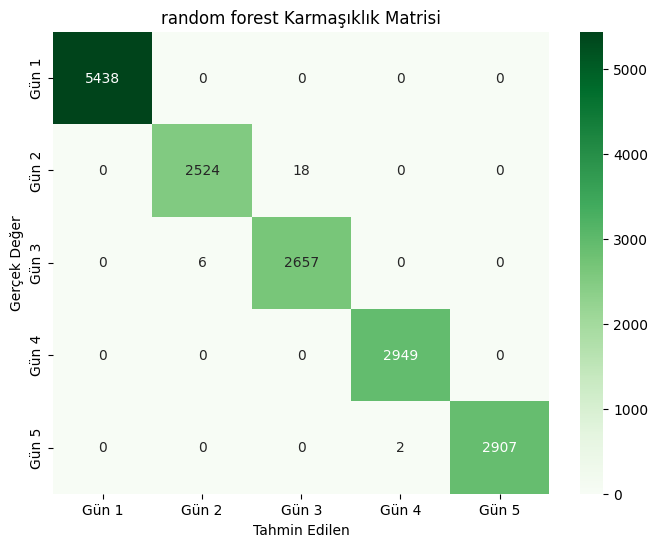

In [20]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=[f'Gün {i}' for i in range(1, 6)],
            yticklabels=[f'Gün {i}' for i in range(1, 6)])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('random forest Karmaşıklık Matrisi')
plt.show()

# 3. model: SVM
* sınıfları birbirinden ayırmak için araya en geniş boşluğu koymaya çalışır, gerekirse boyut atlar.

parametreler:

* kernel: sınırı çizme biçimi (lineer, rbf, poly)
* C: hata payı toleransı (varsayılan: 1.0)
* gamma: tek bir örneğin etkisinin ne kadar uzağa ulaşacağı (varsayılan: scale)

In [21]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C= 1.0, random_state = 42)

In [22]:
svm.fit(x_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [23]:
y_pred_svm = svm.predict(x_test_scaled)

In [24]:
print('doğruluk: ',accuracy_score(y_test, y_pred_svm))
print('\nrapor:\n ',classification_report(y_test, y_pred_svm))

doğruluk:  0.9954548209199442

rapor:
                precision    recall  f1-score   support

           1       1.00      1.00      1.00      5438
           2       0.99      0.98      0.99      2542
           3       0.98      0.99      0.99      2663
           4       1.00      1.00      1.00      2949
           5       1.00      1.00      1.00      2909

    accuracy                           1.00     16501
   macro avg       0.99      0.99      0.99     16501
weighted avg       1.00      1.00      1.00     16501



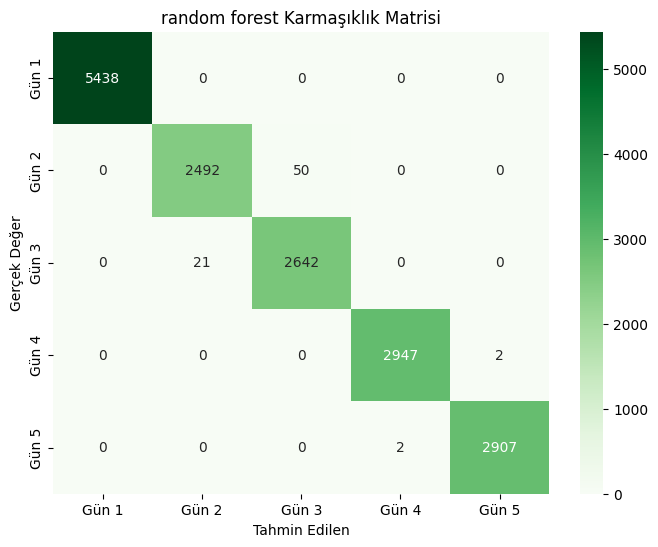

In [25]:
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=[f'Gün {i}' for i in range(1, 6)],
            yticklabels=[f'Gün {i}' for i in range(1, 6)])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('random forest Karmaşıklık Matrisi')
plt.show()

# kıyas
* karşılaştırmayı sırasıyla; accuracy_score, precision, recall, f1_score üzerinden yapıcaz
* daha sonrasında elde ettiğimiz tüm sonuçları özet şeklinde yorumlayacağız

In [42]:
from sklearn.metrics import precision_recall_fscore_support

# Anahtar (key) : model ismi, değer (value) : tahmin vektörleri ni içeren sözlük yapısı.
modeller = {
    'KNN': y_pred_knn,
    'RF': y_pred_rf,
    'SVM': y_pred_svm
}

# her modelin performans sonuçlarını ilk önce sözlükte toplicaz daha sonra dataframe yapıcaz (concat işlemi tekrar tekrar, bilgisayarı çok yorar)
sonuclar = []

# name: model isimleri, pred: model tahmin verileri. 
# .items : teker teker key-value çeker.  key = name, value = preds
for name, preds in modeller.items():

    # çoklu sınıf değerlendirmesi için weighted(ağırlıklı ortalama) kullandık
    # sınıflardaki örnek sayılarını dikkate alarak haksızlığı önlemektir amaç.
    precision, recall, f1 , _ = precision_recall_fscore_support(y_test, preds, average='weighted')
    acc = accuracy_score(y_test, preds)

    # sözlük formatında depoladık
    sonuclar.append({
        'model': name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

kiyas_df = pd.DataFrame(sonuclar)
kiyas_df

,model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.998727,0.998732,0.998727,0.998727
1,RF,0.998424,0.998428,0.998424,0.998424
2,SVM,0.995455,0.995473,0.995455,0.995454


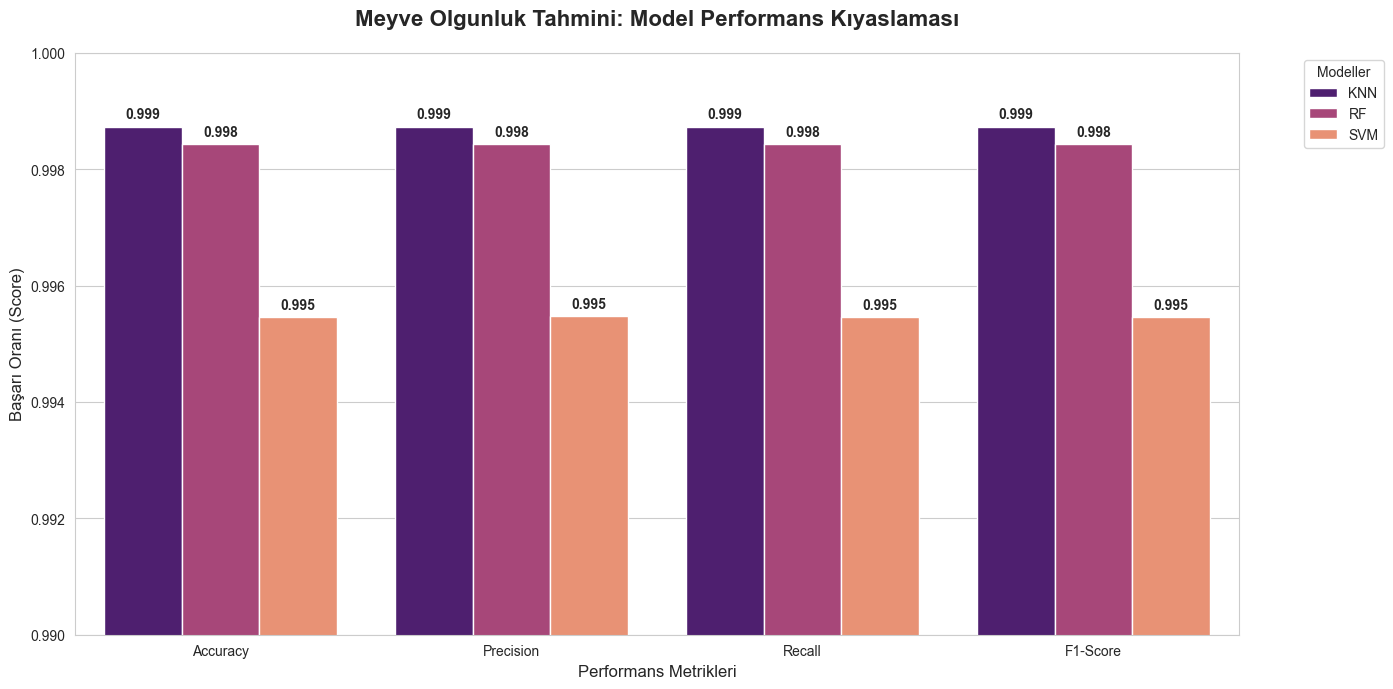

In [51]:
# gözle net görülmesi için geminiye bar plot yaptırttım. görselleştirmeyi yeterince bilmiyorum.

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi Görselleştirmeye Uygun Formata Getirme (Melting)
# 'Model' sütununu sabit tutarak diğer metrikleri satır bazlı hale getiriyoruz
kiyas_melted = kiyas_df.melt(id_vars="model", var_name="Metrik", value_name="Skor")

# 2. Grafik Tasarımı (Plotting)
plt.figure(figsize=(14, 7))


# Renk paletini ve sütunları tanımlıyoruz
bar_plot = sns.barplot(data=kiyas_melted, x="Metrik", y="Skor", hue="model", palette="magma")

# 3. Grafik Detayları ve Etiketler
plt.title("Meyve Olgunluk Tahmini: Model Performans Kıyaslaması", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Performans Metrikleri", fontsize=12)
plt.ylabel("Başarı Oranı (Score)", fontsize=12)
plt.ylim(0.99, 1.0) # Farkları daha net görmek için alt sınırı 0.99 yapıyoruz

# Değerleri sütunların üzerine yazdıralım (Annotation)
for p in bar_plot.patches:
    if p.get_height() > 0: # Sadece 0'dan büyük değerleri yazdır
        bar_plot.annotate(format(p.get_height(), '.3f'), 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha = 'center', va = 'center', 
                        xytext = (0, 9), 
                        textcoords = 'offset points',
                        fontsize=10, fontweight='bold')

plt.legend(title="Modeller", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 🏁 Final Teknik Değerlendirme ve Model Karşılaştırması

Bu çalışmada, **82.505 satırlık** geniş ölçekli bir veri seti üzerinde, 5 günlük muz olgunlaşma sürecini tahmin etmek amacıyla üç farklı makine öğrenmesi algoritması (k-NN, Random Forest ve SVM) test edilmiştir. Model girdileri olarak, yapılan görsel analizler sonucunda en kararlı trendi sergileyen **MQ3**, **MQ5** ve **MQ135** sensörleri seçilmiştir.

---

### 1. Model Bazlı Analitik İncelemeler

#### **🛰️ k-Nearest Neighbors (k-NN) - En Yüksek Başarı** 🏆
* **Performans:** **%99.87** doğruluk oranı ile veri setindeki en başarılı model olmuştur.
* **Analiz:** Sensör verilerindeki günden güne değişimin (özellikle MQ3 ve MQ135) oldukça belirgin ve ayrışık olması, k-NN'in mesafe tabanlı algoritmasının sınıfları neredeyse hatasız kümelemesini sağlamıştır.

#### **🌲 Random Forest (RF)**
* **Performans:** **%99.84** doğruluk ile k-NN modelini çok yakından takip etmiştir.
* **Analiz:** Karar ağaçları topluluğu, sensör verilerindeki mikro değişimleri ve örüntüleri başarıyla yakalamıştır. Verideki gürültülere karşı direnci yüksektir.

#### **🛡️ Support Vector Machines (SVM)**
* **Performans:** **%99.54** doğruluk oranı sergilemiştir.
* **Analiz:** RBF çekirdeği (kernel) sayesinde, sensör verilerindeki doğrusal olmayan geçişleri başarıyla modellemiş ve sınıflar arasına keskin karar sınırları çizmiştir.

---

### 📈 Karşılaştırmalı Performans Matrisi (Gerçek Test Sonuçları)

Elde edilen test sonuçlarına göre modellerin performans özeti aşağıdadır:

| Model | Accuracy | Precision | Recall | F1-Score |
| :--- | :---: | :---: | :---: | :---: |
| **KNN** | **0.998727** | **0.998732** | **0.998727** | **0.998727** |
| **Random Forest** | 0.998424 | 0.998428 | 0.998424 | 0.998424 |
| **SVM** | 0.995455 | 0.995473 | 0.995455 | 0.995454 |

---

### 💡 Mühendislik Çıkarımları ve Önemli Notlar
* **Sensör Etkisi:** MQ3 (Alkol), MQ135 (Hava Kalitesi) ve MQ5 (Metan) sensör kombinasyonu, muz olgunluk aşamalarını belirlemede son derece yüksek bir ayırt ediciliğe sahiptir.
* **Ön İşleme (Preprocessing):** Çalışmanın başında yaşanan **%33** doğruluk hatası, test verilerinin ölçeklendirilmeden (unscaled) modele sunulmasından kaynaklanmıştır. `StandardScaler` uygulamasının ardından başarı oranı **%99.8** seviyesine çıkmıştır.
* **Gelecek Çalışma:** Gaz sensörlerinin çevresel koşullardan (nem/sıcaklık) etkilenme payını minimize etmek için sisteme bir **DHT22** sensörü entegre edilerek veri setinin zenginleştirilmesi önerilir. ayrıca bme688 konmalıdır.

## proje için donanımsal notlar
* MQ sensör içindeki ısıtıcı çok akım çekmektedir. ısıtıcı çalıştığında voltaj düşer ve sensörün okuduğu değer 'gürültü' çok artar anlık olarak. bunu engellemek için sensörün beslemesi arduino ile değil harici bir 5V kaynaktan yapılmalıdır(gerilim bölücü)
* sensörler açık havada olmamalı, küçük nir fanın hava üflediği kapalı kutuda olmalı. hava akışı stabil olmalı yoksa sensör üstündeki gaz yoğunluğu zamanla değişim gösterir.
* her sabah; sistemi sıfırlamak(baz) yani temiz hava çekmek sonrada onu başlangıç değeri olarak almak lazım, her günün başlangıç değeri sensör drift ve yaşlanmadan dolayı değişmesi beklenmektedir (baseline correction için)
* sıcaklık artarsa, ortamda gaz olmadan MQ sensör direnci değişir ve model 'meyve bozuluyor' sanar. bunun için bosch sensörden gelen 'sıcaklık - nem - basınç' verileri de modele feature olarak eklenmeli, model sıcaklık arttığında etkilenmiceği şekilde kendi kendini eğiticektir.
* Sensör verilerini dijitale çeviren ADC biriminin çözünürlüğü yüksek olması gerekiyor. arduinoda standart 10-bit bulunuyor. sensördeki en küçük değişimi algılamak adına 12-16 bit ADC kullanmamız gerekibilir. daha sonra bu konu hakkında daha detaylı ve ne kadar etkili olduğuyla ilgili bir araştırma yapılması gerekiyor.

## proje için yazılımsal notlar
* delta değeri: sensörün anlık değeri bakarsak sapıtabilir(parfüm). belirli bir aralıktaki değişimıne gibi bir orana bakılmalı
* sensör oranları: çevresel gürültü genelde tüm sensörleri benzer oranlarda etkiler bu nedenle örnek: MQ3/MQ5 gibi ayrı bir sütün olarak eklersek gürültüye karşı dirençli olabiliriz, aynı şekilde doğruluk oranımız biraz düşücektir tahminimce.
* basınç kompanzasyonu: basınç arttıkça gaz molekülleri daha sıkışır bu nedenle bosch sensöründen gelen basınç verisiyle gaz yoğunluğunu normalize etmeliyiz.
* bias: modelin çevresel değişkenlere(sıcaklık-nem-basınç) karşı hassasiyetini analiz edip gerekirse matematiksel 'düzeltme katsayısı' uygulanmalıdır